In [35]:
%reload_ext autoreload
%autoreload 2

In [36]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [37]:
from waymo_agent.notebook_imports import *

In [38]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic
from waymo_agent.data_classes.config import ENV_CFG_240step_V08_L01_MR_100_MRNew_20
from waymo_agent.models.evaluate import *
from waymo_agent.models.ppo_model import *
from waymo_agent.models.evaluate import *

In [39]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [40]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

# Run Sim

### Heuristic Agents

In [41]:
env_cfg = ENV_CFG_240step_V08_L01_MR_100_MRNew_20
plt_cfg = PlotConfig()
env_heuristic = RideShareEnv(env_cfg, plot_config=plt_cfg)

Assigned lambda values to nodes. Total lambda: 7.8200 (target: 7.8200)


In [42]:
price_agent = PricingAgent(env_heuristic.config)
dispatch_agent = DispatchAgent(env_heuristic)
reposition_agent = RepositionAgent(env_heuristic)
agents = (price_agent, dispatch_agent, reposition_agent)

### Actor-Critic PPO Model

In [43]:
# env_cfg = EnvConfig(max_episode_steps=60 * 3)
waymo_env = RideShareEnv(env_cfg, plt_cfg)

Assigned lambda values to nodes. Total lambda: 7.8200 (target: 7.8200)


In [44]:
from waymo_agent.models.torch_np_utils import load_weights
from waymo_agent.models.train_utils import PPO_TRN_CFG_TS5k_Debug_EvalEp2, PPOTrainConfig


cfg_ppo = PPO_TRN_CFG_TS5k_Debug_EvalEp2
actor_critic_model = RideShareActorCritic(waymo_env)

In [45]:
model_name = f"ppo_model_V-{waymo_env.config.vehicle_per_node:.2f}_L-{waymo_env.config.lambda_per_node:.2f}_H-{actor_critic_model.model_cfg.hidden_size}_NV-{waymo_env.num_vehicles}_MR-{waymo_env.config.max_pending_requests}"
model_name

'ppo_model_V-0.08_L-0.01_H-256_NV-50_MR-100'

In [46]:
save_path = MODEL_WEIGHT_DIR / f"{model_name}.pt"

In [47]:
load_weights(actor_critic_model, MODEL_WEIGHT_DIR / save_path, DEVICE_TORCH_STR)

RideShareActorCritic(
  (encoder): SharedEncoder(
    (net): Sequential(
      (0): Linear(in_features=1908, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
    )
  )
  (pricing): PricingHead(
    (mu): Linear(in_features=256, out_features=100, bias=True)
  )
  (reposition): RepositionHead(
    (mu): Linear(in_features=256, out_features=100, bias=True)
  )
  (dispatch): DispatchHead(
    (logits_layer): Linear(in_features=256, out_features=5100, bias=True)
  )
  (value): Linear(in_features=256, out_features=1, bias=True)
)

In [48]:
r, info = run_episode(
    waymo_env,
    policy_fn=ppo_policy_stochastic(actor_critic_model),
    seed=0,
    show_progress=True,
    desc="PPO rollout",
)
r

PPO rollout:   0%|          | 0/240 [00:00<?, ?step/s]

-2083.07628308821

In [49]:
r, info = run_episode(
    env_heuristic,
    policy_fn=heuristic_policy(agents),
    seed=0,
    show_progress=True,
    desc="Heuristic rollout",
)

Heuristic rollout:   0%|          | 0/240 [00:00<?, ?step/s]

In [50]:
seeds = list(range(5))
results = eval_paired_seeds(
    waymo_env,
    env_heuristic,
    ppo_policy_stochastic(actor_critic_model),  # policy fn
    heuristic_policy(agents),  # policy fn
    seeds=seeds,
)
results

Evaluating policies:   0%|          | 0/5 [00:00<?, ?episode/s]

{'seeds': array([0, 1, 2, 3, 4]),
 'ppo': array([-2027.66472901, -2095.2161853 , -2061.3364973 , -2040.65218685,
        -2129.35777542]),
 'heur': array([1667.26644679, 1892.11502911, 1927.25648863, 1919.15215612,
        1782.29889041]),
 'diff': array([-3694.9311758 , -3987.33121441, -3988.59298593, -3959.80434297,
        -3911.65666583]),
 'ppo_mean': -2070.845474776227,
 'ppo_std': 41.48569919523179,
 'heur_mean': 1837.6178022114934,
 'heur_std': 111.5041019478928,
 'diff_mean': -3908.4632769877207,
 'diff_std': 123.37238632993727,
 'win_rate': 0.0}

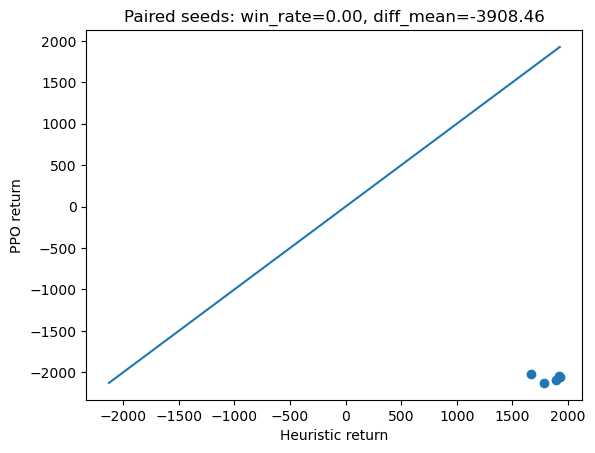

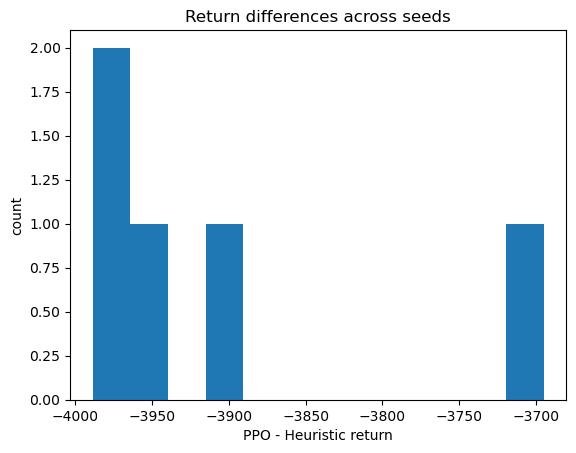

In [51]:
plot_min_eval(results)

In [52]:
results.keys()

dict_keys(['seeds', 'ppo', 'heur', 'diff', 'ppo_mean', 'ppo_std', 'heur_mean', 'heur_std', 'diff_mean', 'diff_std', 'win_rate'])

In [53]:
import torch, math


def fmt_gb(x):
    return f"{x/1024**3:.2f} GB"


if torch.backends.mps.is_available():
    rec = torch.mps.recommended_max_memory()
    drv = torch.mps.driver_allocated_memory()
    cur = torch.mps.current_allocated_memory()
    print("MPS recommended max:", fmt_gb(rec))
    print("MPS driver allocated:", fmt_gb(drv), f"({drv/rec:.1%} of recommended)")
    print("MPS current allocated:", fmt_gb(cur), "(tensors only, excludes cache)")
else:
    print("MPS not available on this machine.")

MPS recommended max: 24.96 GB
MPS driver allocated: 0.06 GB (0.2% of recommended)
MPS current allocated: 0.02 GB (tensors only, excludes cache)
